In [35]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]



(39209, 8)


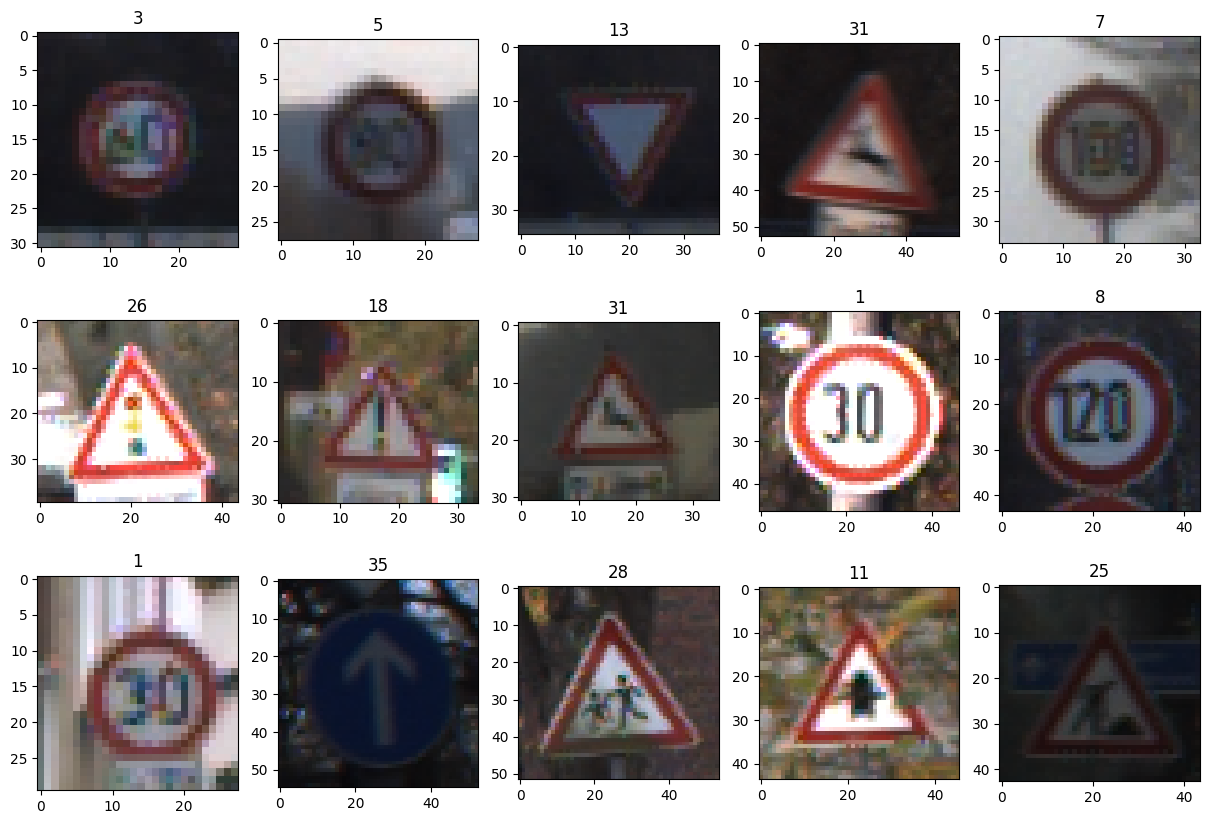

In [54]:
# Load the training labels
root = '/Users/iivaniv/computer_vision_data/archive/' # Path to the dataset location, e.g.
data = pd.read_csv(os.path.join(root, 'Train.csv'))

print(data.shape)

# Number of training samples (amount of samples in data)
num_samples = 39209

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

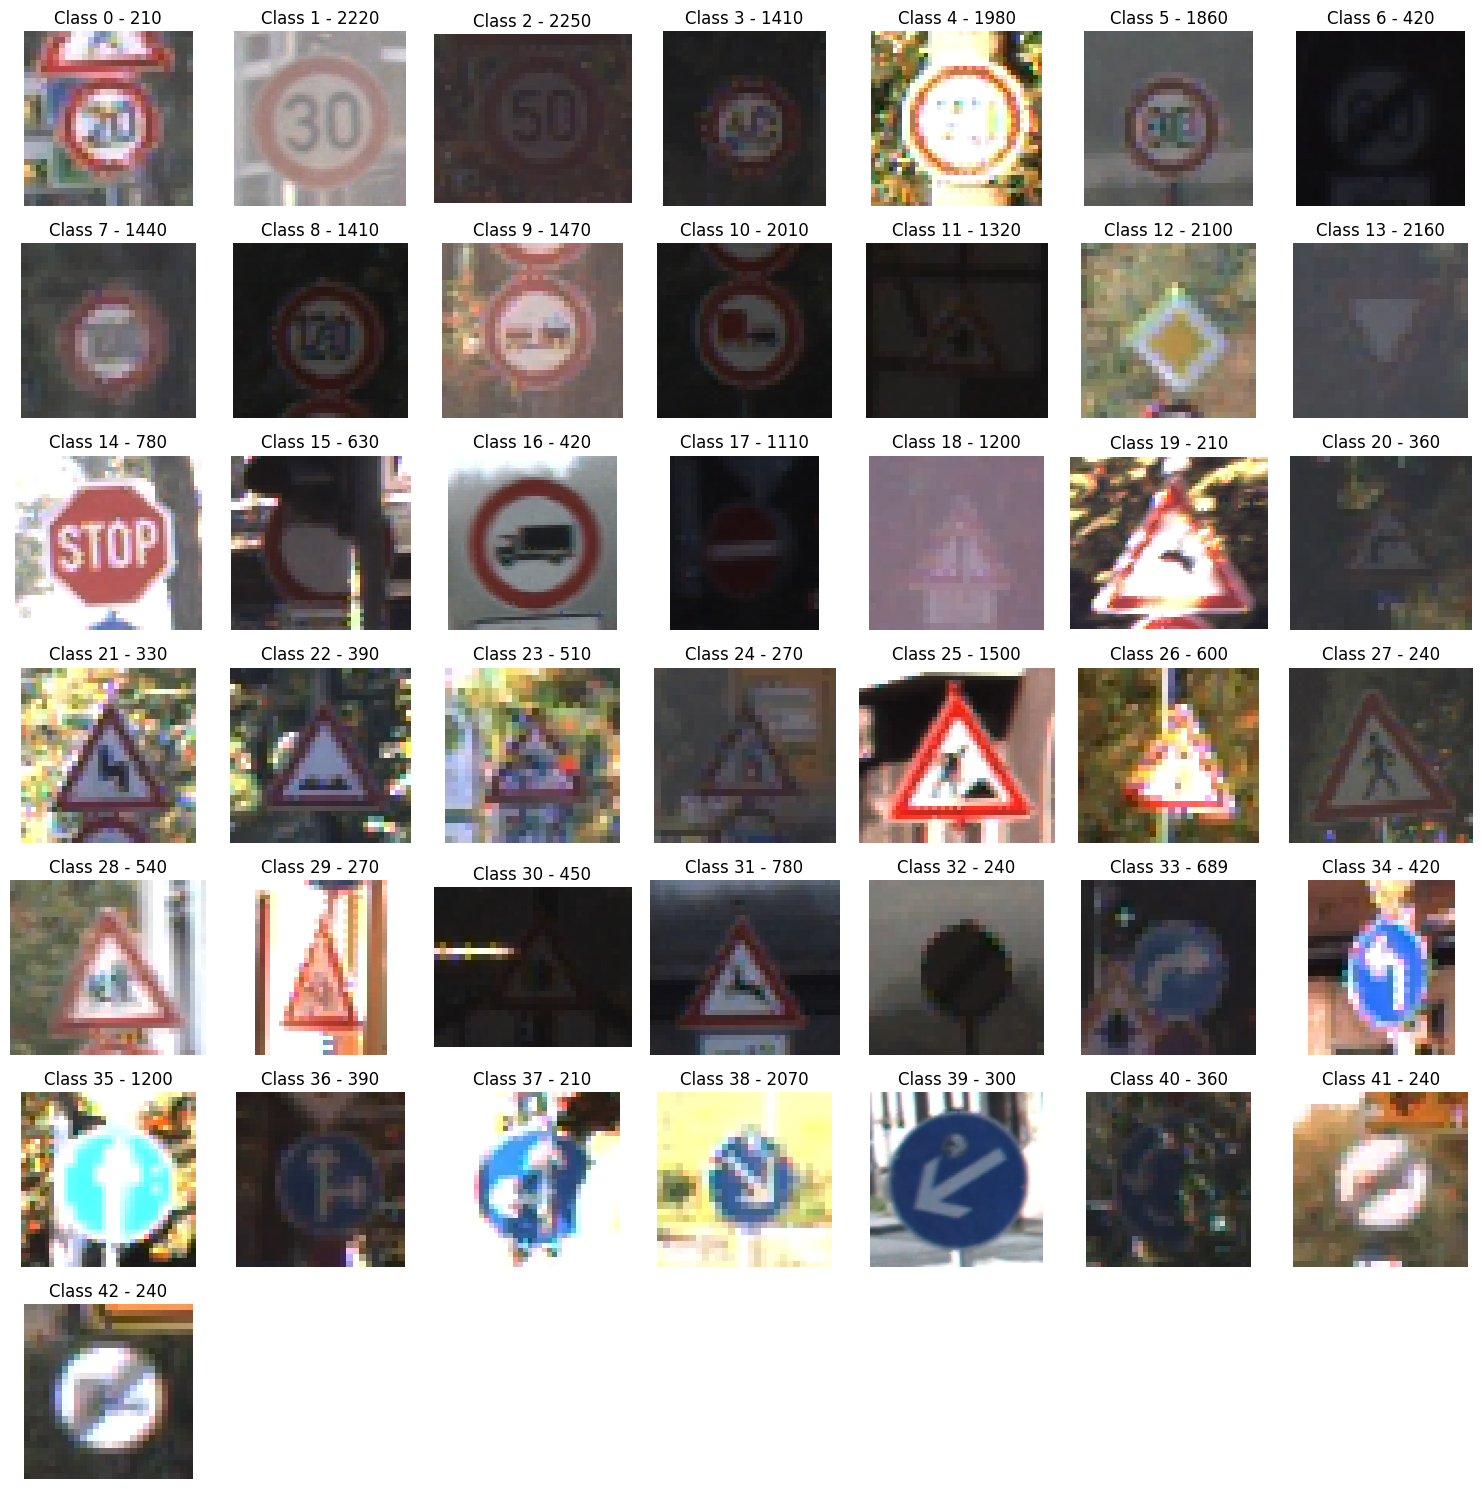

In [63]:
root = '/Users/iivaniv/computer_vision_data/archive/'  # Path to the dataset
data = pd.read_csv(os.path.join(root, 'Train.csv'))


# Create a figure
plt.figure(figsize=(15, 15))

# Iterate through all class IDs (0–42)
for class_id in range(43):
    # Get first sample of this class
    sample = data[data['ClassId'] == class_id].iloc[0]
    count = len(data[data['ClassId'] == class_id]);
    
    img_path = os.path.join(root, sample['Path'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Plot it
    plt.subplot(7, 7, class_id + 1)
    plt.imshow(img)
    plt.title(f"Class {class_id} - {count}")
    plt.axis('off')

plt.tight_layout()
plt.show()

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

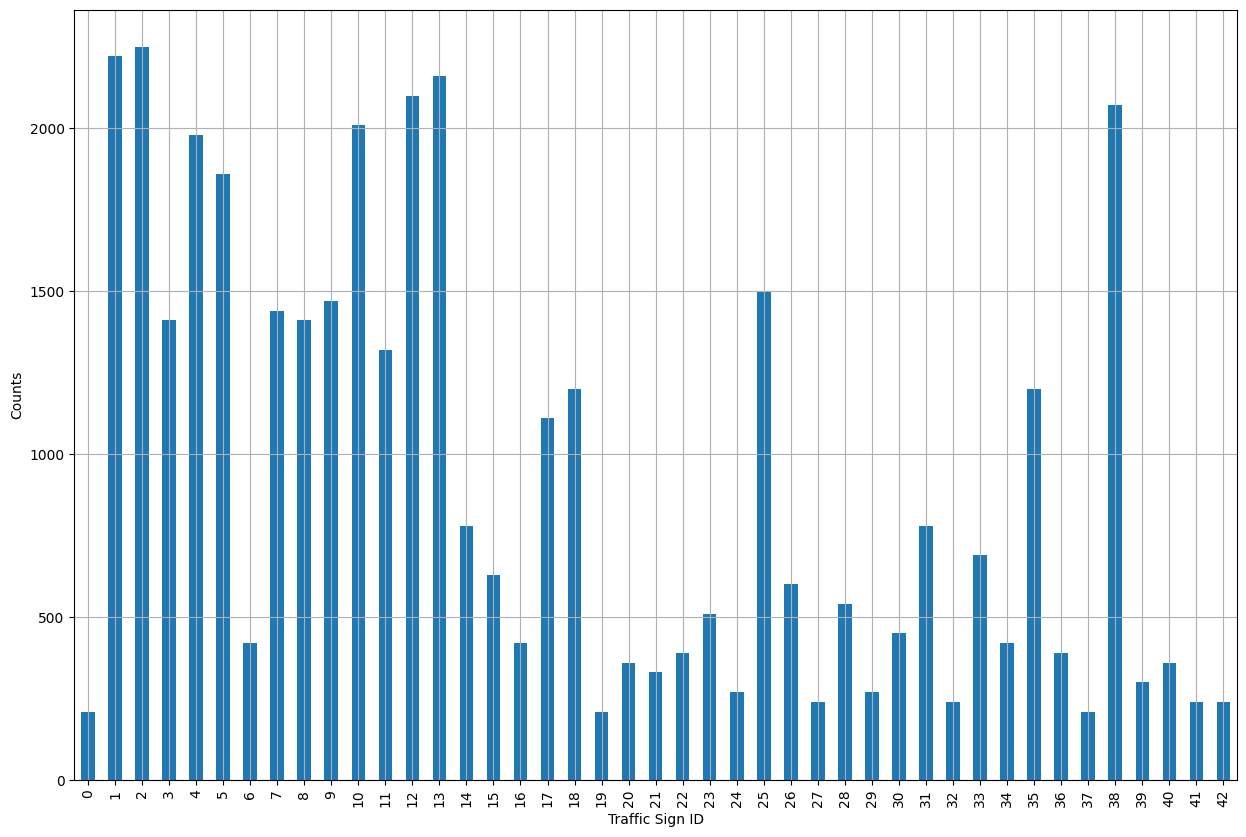

In [67]:
# Extract class identifiers
# Hint: Check the csv 
data = pd.read_csv(os.path.join(root, 'Train.csv'))
ids = data['ClassId']

hist = ids.value_counts().sort_index()
# print(hist)

hist.plot(kind='bar'), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')


# Do you consider the dataset to be balanced? If so, why? If not, why?
    # A quick look shows that the dataset is not balanced. But I think some type of sign is not so common. This explains why the dataset contains relatively few images. 
    # Example: If we take a glance on sign Class_1 (20km/h speed restriction). 
    #          It’s a rare sign — you’re much more likely to see Class 2 (30 km/h restriction) or Class 3 (50 km/h restriction)
# Are there any classes that are (significantly) over-represented or under-represeneted?
    # I partialy answered this in the first question. But it could also depend on right-hand or left-hand traffic
    # Also I must admit there much more examples of restriction signs than other type that explain a lot about Germany :)  